In [1]:
import os
import json
import pandas as pd
# from datetime import datetime
from dotenv import load_dotenv

from options import OptionSurface, Deribit, OKX, Bybit
from portfolio_management import Portfolio
from api_client import TradingDeskAPI
# from scanner import MarketScanner

In [ ]:
# Initialize all classes and parameters

load_dotenv(r"D:/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
# load_dotenv(r"C:/Users/brian/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
BASE_URL = os.getenv("BASE_URL")
USER_EMAIL = os.getenv("USER_EMAIL")
USER_PASSWORD = os.getenv("USER_PASSWORD")
JWT_TOKEN = os.getenv("JWT")
DATA_DIR = os.getenv("DATA_DIR")
FRACTION = float(os.getenv("FRACTION"))
MAX_POSITION = float(os.getenv("MAX_POSITION"))
ENTRY_EV_THRESHOLD = float(os.getenv("ENTRY_EV_THRESHOLD")) # require 1% edge, default = 0
EXIT_EV_THRESHOLD = float(os.getenv("EXIT_EV_THRESHOLD"))
print(BASE_URL)

with open(f"{DATA_DIR}/crypto_tag_ids.json", "r") as f:
    crypto_tag_ids = set(json.load(f))

s = OptionSurface()
portfolio = Portfolio()
api = TradingDeskAPI(base_url=BASE_URL, email=USER_EMAIL, password=USER_PASSWORD, token=JWT_TOKEN)
# scanner = MarketScanner(api=api)

# target_expiry_str = "25DEC26"
# target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")

currencies = ["BTC", "ETH"]
# currencies = ["BTC", "ETH", "HYPE", "SOL", "ZEC"]

https://alphasignal-dev.moretoncp.com


In [3]:
# 9. Get current markets
all_markets_df = api.get_all_markets(DATA_DIR=DATA_DIR, count_limit=10, liquidity_num_min=10000, volume_num_min=5000)
all_markets_df.head()

Fetched 100 markets | Total: 100
Fetched 100 markets | Total: 200
Fetched 100 markets | Total: 300
Fetched 100 markets | Total: 400
Fetched 100 markets | Total: 500
Fetched 100 markets | Total: 600
Fetched 100 markets | Total: 700
Fetched 100 markets | Total: 800
Fetched 100 markets | Total: 900
Fetched 100 markets | Total: 1,000


,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,version,negRiskMarketID,seriesColor,showGmpSeries,showGmpOutcome,oneHourPriceChange,umaResolutionStatus,eventStartTime,gameStartTime,groupItemRange
0,559651,Xi Jinping out before 2027?,0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52e...,xi-jinping-out-before-2027,,2026-12-31T00:00:00Z,165852.97162,2025-07-03T20:37:00.228Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
1,559652,Will Gavin Newsom win the 2028 Democratic pres...,0x0f49db97f71c68b1e42a6d16e3de93d85dbf7d4148e3...,will-gavin-newsom-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,300589.71633,2025-07-11T18:35:56.805Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
2,559653,Will Alexandria Ocasio-Cortez win the 2028 Dem...,0xe6bcc2f1dd025ce5e1833190f7c60a71171c94f805df...,will-alexandria-ocasio-cortez-win-the-2028-dem...,,2028-11-07T00:00:00Z,324397.56997,2025-07-11T18:35:59.075Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
3,559654,Will Pete Buttigieg win the 2028 Democratic pr...,0x4c325469d9b516ef4e6b8f73a81a12607dec075e3c2f...,will-pete-buttigieg-win-the-2028-democratic-pr...,,2028-11-07T00:00:00Z,523131.81014,2025-07-11T18:35:58.818Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
4,559655,Will Josh Shapiro win the 2028 Democratic pres...,0xd65891729ce093cc12236856837eba1a0872fc7998fd...,will-josh-shapiro-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,477356.5287,2025-07-11T18:36:01.098Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN


In [4]:
df[df["market_index"] == 586]

,timestamp,price,market_index,question,token_id
38652,2025-11-24 19:50:22+00:00,0.565,586,"Will Ethereum reach $3,500 by December 31, 2026?",1147959821886634285649175971677163793464218117...
38653,2025-11-24 20:00:10+00:00,0.570,586,"Will Ethereum reach $3,500 by December 31, 2026?",1147959821886634285649175971677163793464218117...
38654,2025-11-24 20:10:08+00:00,0.570,586,"Will Ethereum reach $3,500 by December 31, 2026?",1147959821886634285649175971677163793464218117...
38655,2025-11-24 20:20:08+00:00,0.570,586,"Will Ethereum reach $3,500 by December 31, 2026?",1147959821886634285649175971677163793464218117...
38656,2025-11-24 20:30:11+00:00,0.595,586,"Will Ethereum reach $3,500 by December 31, 2026?",1147959821886634285649175971677163793464218117...
...,...,...,...,...,...
77078,2026-08-26 08:20:13+00:00,0.305,586,"Will Ethereum reach $3,500 by December 31, 2026?",1147959821886634285649175971677163793464218117...
77079,2026-08-26 08:30:11+00:00,0.305,586,"Will Ethereum reach $3,500 by December 31, 2026?",1147959821886634285649175971677163793464218117...
77080,2026-08-26 08:40:11+00:00,0.305,586,"Will Ethereum reach $3,500 by December 31, 2026?",1147959821886634285649175971677163793464218117...
77081,2026-08-26 08:50:15+00:00,0.305,586,"Will Ethereum reach $3,500 by December 31, 2026?",1147959821886634285649175971677163793464218117...


In [12]:
columns = [
    "Open time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Close time",
    "Quote asset volume",
    "Number of trades",
    "Taker buy base asset volume",
    "Taker buy quote asset volume",
    "Ignore"
]
eth_spot = pd.read_csv(r"C:\Users\brian\Desktop\ETHUSDT-5m-2026-07.csv", header=None,
    names=columns)
eth_spot["Open time"] = pd.to_datetime(eth_spot["Open time"], unit="us", utc=True).astype("datetime64[ms, UTC]")
eth_spot = eth_spot.rename(columns={
    "Open time": "timestamp"
})
eth_spot

,timestamp,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2026-07-01 00:00:00+00:00,1572.00,1574.90,1572.00,1574.89,1027.9291,1782864299999999,1.617077e+06,10286,558.8982,879413.077314,0
1,2026-07-01 00:05:00+00:00,1574.88,1575.43,1572.40,1572.66,423.1894,1782864599999999,6.662777e+05,5066,243.7465,383755.586836,0
2,2026-07-01 00:10:00+00:00,1572.65,1574.86,1572.65,1574.06,677.9353,1782864899999999,1.066965e+06,6295,511.4244,804925.835289,0
3,2026-07-01 00:15:00+00:00,1574.06,1575.39,1570.51,1570.51,285.7142,1782865199999999,4.493991e+05,3479,141.2795,222283.326172,0
4,2026-07-01 00:20:00+00:00,1570.52,1571.55,1568.31,1568.73,535.4685,1782865499999999,8.404076e+05,5142,214.7103,337004.095073,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8923,2026-07-31 23:35:00+00:00,1864.16,1864.18,1863.34,1863.92,116.3118,1785541199999999,2.167966e+05,2097,63.0753,117561.998593,0
8924,2026-07-31 23:40:00+00:00,1863.91,1864.12,1863.27,1863.61,114.0950,1785541499999999,2.126254e+05,2092,75.2980,140318.907203,0
8925,2026-07-31 23:45:00+00:00,1863.61,1863.74,1862.19,1862.19,225.3369,1785541799999999,4.197900e+05,3389,82.7456,154164.207555,0
8926,2026-07-31 23:50:00+00:00,1862.20,1863.28,1860.95,1861.76,365.4604,1785542099999999,6.806170e+05,5815,104.5064,194609.703588,0


In [44]:
from pathlib import Path
import pandas as pd
columns = [
    "Open time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Close time",
    "Quote asset volume",
    "Number of trades",
    "Taker buy base asset volume",
    "Taker buy quote asset volume",
    "Ignore"
]
folder = Path(r"C:\Users\brian\Desktop")
print("Folder exists:", folder.exists())
print("Folder:", folder)
files = sorted(folder.glob("ETHUSDT*.csv"))

dfs = []

for file in files:
    # Extract meeting date from filename

    eth_spot = pd.read_csv(file, header=None,
    names=columns)

    eth_spot["Open time"] = pd.to_datetime(eth_spot["Open time"], unit="us", utc=True).astype("datetime64[ms, UTC]")
    eth_spot = eth_spot.rename(columns={
        "Open time": "timestamp"
    })

    dfs.append(eth_spot)

eth = pd.concat(dfs, ignore_index=True)
eth = eth.sort_values("timestamp")
eth.to_parquet("eth_spot_historical_price.parquet")

Folder exists: True
Folder: C:\Users\brian\Desktop


In [46]:
eth_spot = pd.read_parquet("eth_spot_historical_price.parquet")
eth_spot

,timestamp,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2025-10-01 00:00:00+00:00,4145.15,4151.41,4144.65,4151.41,1038.4316,1759277099999999,4.308127e+06,17178,723.1062,2.999765e+06,0
1,2025-10-01 00:05:00+00:00,4151.41,4152.37,4148.33,4149.14,620.0314,1759277399999999,2.573722e+06,9562,324.4493,1.346717e+06,0
2,2025-10-01 00:10:00+00:00,4149.14,4149.25,4144.35,4145.84,670.3296,1759277699999999,2.779812e+06,7880,262.0305,1.086663e+06,0
3,2025-10-01 00:15:00+00:00,4145.85,4147.04,4140.17,4144.72,719.1728,1759277999999999,2.979700e+06,13383,251.3857,1.041454e+06,0
4,2025-10-01 00:20:00+00:00,4144.72,4145.35,4136.04,4137.47,1241.2362,1759278299999999,5.136679e+06,13317,294.1102,1.216943e+06,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87547,2026-07-31 23:35:00+00:00,1864.16,1864.18,1863.34,1863.92,116.3118,1785541199999999,2.167966e+05,2097,63.0753,1.175620e+05,0
87548,2026-07-31 23:40:00+00:00,1863.91,1864.12,1863.27,1863.61,114.0950,1785541499999999,2.126254e+05,2092,75.2980,1.403189e+05,0
87549,2026-07-31 23:45:00+00:00,1863.61,1863.74,1862.19,1862.19,225.3369,1785541799999999,4.197900e+05,3389,82.7456,1.541642e+05,0
87550,2026-07-31 23:50:00+00:00,1862.20,1863.28,1860.95,1861.76,365.4604,1785542099999999,6.806170e+05,5815,104.5064,1.946097e+05,0


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_parquet("crypto_price_history_df.parquet")

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Pick one market index
market_index = 587

# Filter to that index
df_index = df[df["market_index"] == market_index].copy()

# Sort chronologically
df_index = df_index.sort_values("timestamp")

merged = pd.merge_asof(
    df_index,
    eth_spot.sort_values("timestamp"),
    on="timestamp",
    direction="backward",
    tolerance=pd.Timedelta("5min")
)

merged = merged[merged["Open"] > 0]

merged["eth_return_10m"] = (
    np.log(merged["Close"])
    .diff(2)
)

merged["eth_return_20m"] = (
    np.log(merged["Close"])
    .diff(4)
)

merged["eth_return_30m"] = (
    np.log(merged["Close"])
    .diff(6)
)

intervals = [10, 20, 30, 60, 120, 180, 1440]

for minutes in intervals:
    steps = minutes // 10
    print(steps)

    merged[f"yes_future_{minutes}m"] = (
        merged["price"].shift(-steps)
    )

    merged[f"yes_change_{minutes}m"] = (
        merged[f"yes_future_{minutes}m"] - merged["price"]
    )
merged

1
2
3
6
12
18
144


,timestamp,price,market_index,question,token_id,Open,High,Low,Close,Volume,...,yes_future_30m,yes_change_30m,yes_future_60m,yes_change_60m,yes_future_120m,yes_change_120m,yes_future_180m,yes_change_180m,yes_future_1440m,yes_change_1440m
0,2025-11-24 19:50:19+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2958.64,2965.48,2956.81,2957.74,1177.4771,...,0.445,0.0,0.445,0.0,0.45,0.005,0.450,0.005,0.495,0.05
1,2025-11-24 20:00:07+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2959.00,2965.60,2954.22,2956.53,1393.1693,...,0.445,0.0,0.445,0.0,0.45,0.005,0.455,0.010,0.495,0.05
2,2025-11-24 20:10:06+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2968.26,2987.00,2967.17,2976.22,4601.1598,...,0.445,0.0,0.445,0.0,0.45,0.005,0.455,0.010,0.495,0.05
3,2025-11-24 20:20:06+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2979.19,2982.44,2975.62,2976.86,1282.7656,...,0.445,0.0,0.445,0.0,0.45,0.005,0.450,0.005,0.495,0.05
4,2025-11-24 20:30:07+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2978.51,2978.77,2970.84,2974.50,1058.2884,...,0.445,0.0,0.445,0.0,0.45,0.005,0.450,0.005,0.495,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34994,2026-07-31 23:10:10+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1862.99,1863.58,1862.39,1862.45,292.9915,...,0.486,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34995,2026-07-31 23:20:14+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1863.68,1864.65,1863.30,1863.50,276.7017,...,0.486,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34996,2026-07-31 23:30:12+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1864.05,1864.77,1863.55,1864.17,111.8501,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34997,2026-07-31 23:40:11+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1863.91,1864.12,1863.27,1863.61,114.0950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
import statsmodels.api as sm
models = {}

for horizon in [10, 20, 30, 60, 120, 180, 1440]:
    test = merged[
        ["eth_return_10m", f"yes_change_{horizon}m"]
    ].dropna()

    X = sm.add_constant(test["eth_return_10m"])
    y = test[f"yes_change_{horizon}m"]

    model = sm.OLS(y, X).fit()
    models[horizon] = model.params.iloc[1]
    
    print(f"\n{horizon}m")
    print(f"beta: {model.params.iloc[1]:.6f}")
    print(f"t-stat: {model.tvalues.iloc[1]:.3f}")
    print(f"p-value: {model.pvalues.iloc[1]:.6f}")
    print(f"R²: {model.rsquared:.4f}")


10m
beta: -0.124579
t-stat: -16.158
p-value: 0.000000
R²: 0.0074

20m
beta: -0.184855
t-stat: -19.725
p-value: 0.000000
R²: 0.0110

30m
beta: -0.229073
t-stat: -21.308
p-value: 0.000000
R²: 0.0128

60m
beta: -0.334624
t-stat: -23.918
p-value: 0.000000
R²: 0.0161

120m
beta: -0.417629
t-stat: -22.966
p-value: 0.000000
R²: 0.0149

180m
beta: -0.515165
t-stat: -23.643
p-value: 0.000000
R²: 0.0157

1440m
beta: -0.829121
t-stat: -14.741
p-value: 0.000000
R²: 0.0062


In [58]:
def fee(price):
    return 0.07 * price * (1 - price)

def sortino(x, target=0):
    x = pd.Series(x).dropna()

    downside = np.minimum(x - target, 0)

    downside_dev = np.sqrt(
        np.mean(downside ** 2)
    )

    if downside_dev == 0:
        return np.nan

    return (
        x.mean() - target
    ) / downside_dev

spread = 0.01
half_spread = spread / 2

thresholds = [
    0.005,
    0.01,
    0.015,
    0.02,
    0.03,
    0.05,
    0.10,
    0.20
]

results = []

for threshold in thresholds:

    for horizon in [10, 20, 30, 60, 120, 180, 1440]:

        beta = models[horizon]
        
        s = merged.copy()

        # --------------------------------
        # SIGNAL
        # --------------------------------

        s["predicted_yes_change"] = (
            beta * s["eth_return_10m"]
        )

        s["signal"] = 0

        s.loc[
            s["predicted_yes_change"] > threshold,
            "signal"
        ] = 1       # BUY YES

        s.loc[
            s["predicted_yes_change"] < -threshold,
            "signal"
        ] = -1      # BUY NO
    
        # --------------------------------
        # ONLY TRADE SIGNALS
        # --------------------------------
        s = s[s["signal"] != 0].copy()

        s["entry_price"] = np.where(
            s["signal"] == 1,
            s["price"] + half_spread,
            1 - s["price"] + half_spread
        )

        s["exit_price"] = np.where(
            s["signal"] == 1,
            s[f"yes_future_{horizon}m"] - half_spread,
            1 - s[f"yes_future_{horizon}m"] - half_spread
        )

        s["entry_fee"] = fee(s["entry_price"])
        s["exit_fee"] = fee(s["exit_price"])

        # --------------------------------
        # GROSS P&L
        # --------------------------------

        s["gross_pnl"] = (
            s["exit_price"]
            - s["entry_price"]
        )

        # --------------------------------
        # NET P&L
        # --------------------------------

        s["net_pnl"] = (
            s["gross_pnl"]
            - s["entry_fee"]
            - s["exit_fee"]
        )

        # --------------------------------
        # RETURN
        # --------------------------------

        s["return"] = (
            s["net_pnl"]
            / s["entry_price"]
        )

        x = s["return"].dropna()

        results.append({
            "threshold": threshold,
            "horizon": horizon,
            "N": len(x),
            "mean_return": x.mean(),
            "median_return": x.median(),
            "win_rate": (x > 0).mean(),
            "sortino": sortino(x),
            "total_pnl": s["net_pnl"].sum()
        })

results_df = pd.DataFrame(results)
results_df
# Small and moderate shocks exhibit statistically negative subsequent price changes, but the edge is too small to overcome transaction costs. Very large shocks may contain a tradable mean-reversion signal, particularly at longer horizons.

,threshold,horizon,N,mean_return,median_return,win_rate,sortino,total_pnl
0,0.005,10,8,-0.037889,-0.060597,0.250000,-0.509456,-0.134950
1,0.005,20,46,-0.062995,-0.060597,0.108696,-0.749953,-1.205300
2,0.005,30,107,-0.060333,-0.064697,0.121495,-0.703527,-2.852051
3,0.005,60,318,-0.060730,-0.066028,0.097484,-0.684359,-9.065059
4,0.005,120,588,-0.065518,-0.065800,0.093537,-0.673114,-18.149052
5,0.005,180,1021,-0.069146,-0.068600,0.090108,-0.689016,-31.388192
6,0.005,1440,2767,-0.058066,-0.069138,0.214312,-0.410505,-85.570641
7,0.010,10,0,NaN,NaN,NaN,NaN,0.000000
8,0.010,20,1,-0.079004,-0.079004,0.000000,-1.000000,-0.026071
9,0.010,30,4,-0.062098,-0.062361,0.000000,-0.838165,-0.086687


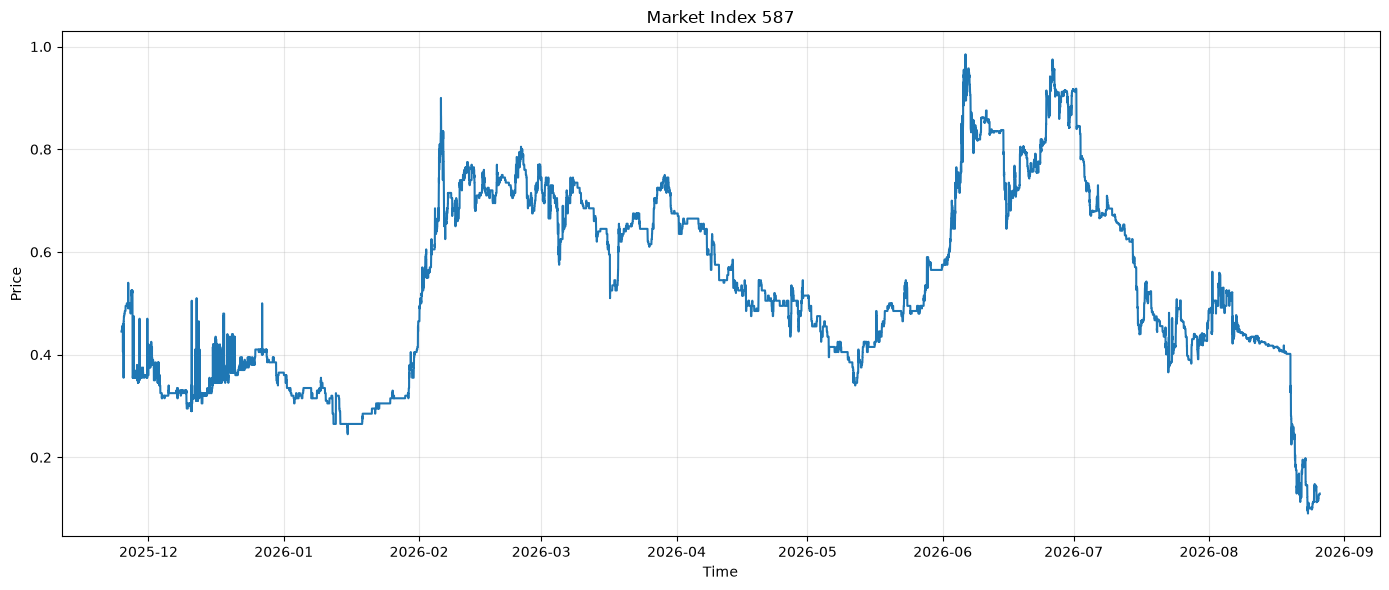

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("crypto_price_history_df.parquet")

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Pick one market index
market_index = 587

# Filter to that index
df_index = df[df["market_index"] == market_index].copy()

# Sort chronologically
df_index = df_index.sort_values("timestamp")

# Plot price over time
plt.figure(figsize=(14, 6))
plt.plot(df_index["timestamp"], df_index["price"])

plt.xlabel("Time")
plt.ylabel("Price")
plt.title(f"Market Index {market_index}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

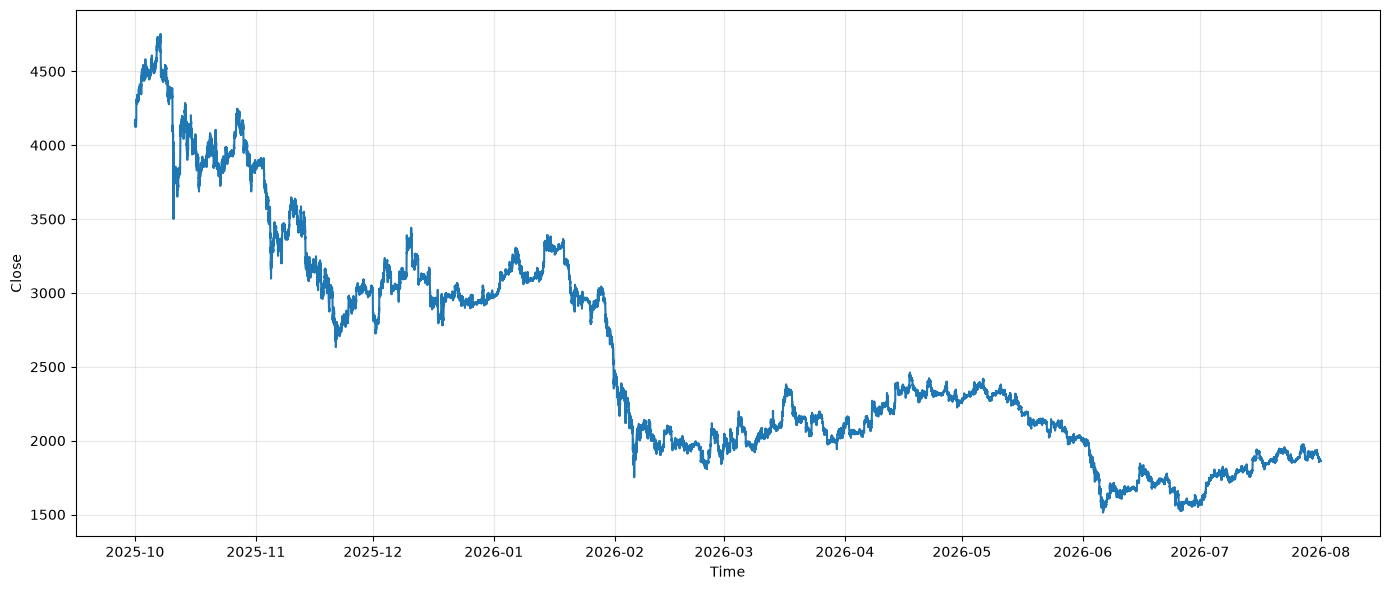

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

df = eth_spot

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# # Pick one market index
# market_index = 587

# # Filter to that index
# df_index = df[df["market_index"] == market_index].copy()

# Sort chronologically
df_index = df.sort_values("timestamp")

# Plot price over time
plt.figure(figsize=(14, 6))
plt.plot(df_index["timestamp"], df_index["Close"])

plt.xlabel("Time")
plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
sum_series = (
    price_history_df.groupby("timestamp")["price"]
    .sum()
)

gender
Men      1.037
Women    1.086
Name: yes_ask, dtype: object

In [28]:
import time
from datetime import datetime, timezone
import requests
def get_price_history(
    token_id: str,
    start_ts: int,
    end_ts: int,
    interval="1m",
    fidelity=10,
):
    url = "https://clob.polymarket.com/prices-history"

    params = {
        "market": token_id,
        "startTs": start_ts,
        "endTs": end_ts,
        "interval": interval,
        "fidelity": fidelity,
    }

    r = requests.get(url, params=params, timeout=30)

    if not r.ok:
        raise RuntimeError(
            f"{r.status_code}: {r.text}"
        )

    return r.json()["history"]


def get_history_chunked(
    token_id: str,
    start_ts: int,
    end_ts: int,
    chunk_days=1,
):
    all_history = []

    chunk_seconds = chunk_days * 24 * 60 * 60

    current = start_ts

    while current < end_ts:
        chunk_end = min(
            current + chunk_seconds,
            end_ts
        )

        print(
            datetime.fromtimestamp(
                current, tz=timezone.utc
            ),
            "->",
            datetime.fromtimestamp(
                chunk_end, tz=timezone.utc
            )
        )

        history = get_price_history(
            token_id,
            current,
            chunk_end,
        )

        all_history.extend(history)

        current = chunk_end

    # Convert to dataframe
    df = pd.DataFrame(all_history)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(
        df["t"],
        unit="s",
        utc=True
    )

    df["price"] = df["p"].astype(float)

    df = df[
        ["timestamp", "price"]
    ]

    # Remove duplicate timestamps caused by chunk boundaries
    df = (
        df
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return df
    
df = markets_df.copy()

now_ts = int(time.time())

all_market_history = {}

for idx, row in df.iterrows():

    token_id = row["yes_token"]

    # Convert createdAt -> Unix timestamp
    created_at = pd.to_datetime(row["createdAt"])
    start_ts = int(created_at.timestamp())

    print("\n" + "=" * 80)
    print(f"Market: {row['question']}")
    print(f"Created: {created_at}")
    print(
        f"Start: {datetime.fromtimestamp(start_ts, tz=timezone.utc)}"
    )

    try:
        history = get_history_chunked(
            token_id=token_id,
            start_ts=start_ts,
            end_ts=now_ts,
            chunk_days=15
        )

        # Keep market metadata
        history["market_index"] = idx
        history["question"] = row["question"]
        history["token_id"] = token_id

        all_market_history[idx] = history

        print(f"Downloaded {len(history):,} observations")

    except Exception as e:
        print(f"ERROR: {e}")

price_history_df = pd.concat(
    all_market_history.values(),
    ignore_index=True
)

print(price_history_df.head())
print(price_history_df.shape)


Market: Will Carlos Alcaraz win the 2026 Men's US Open?
Created: 2026-01-02 17:59:43.884641+00:00
Start: 2026-01-02 17:59:43+00:00
2026-01-02 17:59:43+00:00 -> 2026-01-17 17:59:43+00:00
2026-01-17 17:59:43+00:00 -> 2026-02-01 17:59:43+00:00
2026-02-01 17:59:43+00:00 -> 2026-02-16 17:59:43+00:00
2026-02-16 17:59:43+00:00 -> 2026-03-03 17:59:43+00:00
2026-03-03 17:59:43+00:00 -> 2026-03-18 17:59:43+00:00
2026-03-18 17:59:43+00:00 -> 2026-04-02 17:59:43+00:00
2026-04-02 17:59:43+00:00 -> 2026-04-17 17:59:43+00:00
2026-04-17 17:59:43+00:00 -> 2026-05-02 17:59:43+00:00
2026-05-02 17:59:43+00:00 -> 2026-05-17 17:59:43+00:00
2026-05-17 17:59:43+00:00 -> 2026-06-01 17:59:43+00:00
2026-06-01 17:59:43+00:00 -> 2026-06-16 17:59:43+00:00
2026-06-16 17:59:43+00:00 -> 2026-07-01 17:59:43+00:00
2026-07-01 17:59:43+00:00 -> 2026-07-16 17:59:43+00:00
2026-07-16 17:59:43+00:00 -> 2026-07-31 17:59:43+00:00
2026-07-31 17:59:43+00:00 -> 2026-08-15 17:59:43+00:00
2026-08-15 17:59:43+00:00 -> 2026-08-26 06:

In [48]:
price_history_df = pd.read_parquet("tennis_price_history_df.parquet")
price_history_df = (
    price_history_df.set_index("timestamp")
      .groupby("token_id")
      .resample("10min")
      .agg({
          "price": "last",
          "market_index": "first",
          "question": "first",
      })
      .reset_index()
)
price_history_df

,token_id,timestamp,price,market_index,question
0,1002087609790068157008213655546239890485855419...,2026-01-02 21:00:00+00:00,0.460,925.0,Will Donna Vekic win the 2026 Women’s US Open?
1,1002087609790068157008213655546239890485855419...,2026-01-02 21:10:00+00:00,0.445,925.0,Will Donna Vekic win the 2026 Women’s US Open?
2,1002087609790068157008213655546239890485855419...,2026-01-02 21:20:00+00:00,0.410,925.0,Will Donna Vekic win the 2026 Women’s US Open?
3,1002087609790068157008213655546239890485855419...,2026-01-02 21:30:00+00:00,0.050,925.0,Will Donna Vekic win the 2026 Women’s US Open?
4,1002087609790068157008213655546239890485855419...,2026-01-02 21:40:00+00:00,0.050,925.0,Will Donna Vekic win the 2026 Women’s US Open?
...,...,...,...,...,...
1762670,9802550207568138353041385750563535019776718188...,2026-08-26 05:50:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?
1762671,9802550207568138353041385750563535019776718188...,2026-08-26 06:00:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?
1762672,9802550207568138353041385750563535019776718188...,2026-08-26 06:10:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?
1762673,9802550207568138353041385750563535019776718188...,2026-08-26 06:20:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?


In [51]:
import numpy as np
import pandas as pd

df = price_history_df.copy()

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = (
    df[
        df["price"].between(0, 1)
    ]
    .sort_values(["token_id", "timestamp"])
    .copy()
)

# ---------------------------------------------------------
# 1. Resample to exact 10-minute intervals
# ---------------------------------------------------------

df = (
    df.set_index("timestamp")
      .groupby("token_id")["price"]
      .resample("10min")
      .last()
      .dropna()
      .reset_index()
)

# ---------------------------------------------------------
# 2. Logit transform
# ---------------------------------------------------------

eps = 0.001

p = df["price"].clip(eps, 1 - eps)

df["logit"] = np.log(p / (1 - p))


# ---------------------------------------------------------
# 3. Rolling 24-hour z-score
# ---------------------------------------------------------

# 24 hours = 144 ten-minute observations
window = 144

g = df.groupby("token_id")["logit"]

df["rolling_mean"] = (
    g.transform(
        lambda x:
        x.rolling(
            window,
            min_periods=72
        ).mean()
    )
)

df["rolling_std"] = (
    g.transform(
        lambda x:
        x.rolling(
            window,
            min_periods=72
        ).std()
    )
)

df["zscore"] = (
    (df["logit"] - df["rolling_mean"])
    / df["rolling_std"]
)


# ---------------------------------------------------------
# 4. Future logit changes
# ---------------------------------------------------------

g_logit = df.groupby("token_id")["logit"]

for name, periods in {
    "1h": 6,
    "6h": 36,
    "24h": 144,
    "3d": 432,
}.items():

    df[f"future_logit_{name}"] = (
        g_logit.shift(-periods)
        - df["logit"]
    )

In [53]:
for horizon in ["1h", "6h", "24h", "3d"]:

    signal = df["zscore"] < -2

    result = df.loc[
        signal,
        f"future_logit_{horizon}"
    ].dropna()

    print(
        f"{horizon:>4}",
        f"N={len(result):>7,}",
        f"mean={result.mean():+.5f}",
        f"median={result.median():+.5f}",
        f"win={(result > 0).mean():.3f}"
    )

for horizon in ["1h", "6h", "24h", "3d"]:

    signal = df["zscore"] > 2

    result = df.loc[
        signal,
        f"future_logit_{horizon}"
    ].dropna()

    print(
        f"{horizon:>4}",
        f"N={len(result):>7,}",
        f"mean={result.mean():+.5f}",
        f"median={result.median():+.5f}",
        f"win={(result > 0).mean():.3f}"
    )

  1h N= 84,245 mean=+0.00403 median=+0.00000 win=0.136
  6h N= 84,244 mean=-0.00364 median=+0.00000 win=0.233
 24h N= 83,869 mean=-0.01005 median=+0.00000 win=0.326
  3d N= 83,349 mean=-0.04760 median=+0.00000 win=0.357
  1h N= 56,715 mean=-0.03103 median=+0.00000 win=0.101
  6h N= 56,579 mean=-0.06682 median=+0.00000 win=0.159
 24h N= 56,334 mean=-0.12177 median=-0.02032 win=0.233
  3d N= 55,592 mean=-0.17258 median=-0.06504 win=0.267


In [112]:
market_index = 875

# Filter to this player
player_df = price_history_df[price_history_df["market_index"] == market_index].copy()

alcaraz = (
    price_history_df[
        price_history_df["question"]
        == "Will Carlos Alcaraz win the 2026 Men's US Open?"
    ]
    .copy()
)

alcaraz["timestamp"] = pd.to_datetime(
    alcaraz["timestamp"],
    utc=True
)

alcaraz["price"] = pd.to_numeric(
    alcaraz["price"],
    errors="coerce"
)

alcaraz = (
    alcaraz
    .sort_values("timestamp")
    .reset_index(drop=True)
)

alcaraz.head()

alcaraz["change"] = (
    alcaraz["price"].diff()
)

alcaraz["pct_change"] = (
    alcaraz["price"].pct_change()
)

alcaraz[
    ["timestamp", "price", "change", "pct_change"]
].head(30)

,timestamp,price,change,pct_change
0,2026-01-02 21:00:00+00:00,0.500,NaN,NaN
1,2026-01-02 21:10:00+00:00,0.485,-0.015,-0.030000
2,2026-01-02 21:20:00+00:00,0.465,-0.020,-0.041237
3,2026-01-02 21:30:00+00:00,0.455,-0.010,-0.021505
4,2026-01-02 21:40:00+00:00,0.470,0.015,0.032967
5,2026-01-02 21:50:00+00:00,0.560,0.090,0.191489
6,2026-01-02 22:00:00+00:00,0.560,0.000,0.000000
7,2026-01-02 22:10:00+00:00,0.545,-0.015,-0.026786
8,2026-01-02 22:20:00+00:00,0.525,-0.020,-0.036697
9,2026-01-02 22:30:00+00:00,0.510,-0.015,-0.028571


In [113]:
# Make sure sorted
alcaraz = alcaraz.sort_values("timestamp").reset_index(drop=True)

# Future absolute price changes
for name, periods in {
    "10m": 1,
    "30m": 3,
    "1h": 6,
    "6h": 36,
    "24h": 144,
    "3d": 432,
}.items():

    alcaraz[f"future_change_{name}"] = (
        alcaraz["price"].shift(-periods)
        - alcaraz["price"]
    )

for name in ["10m", "30m", "1h", "6h", "24h", "3d"]:

    alcaraz[f"future_return_{name}"] = (
        alcaraz[f"future_change_{name}"]
        / alcaraz["price"]
    )

In [114]:
signal = alcaraz["change"] >= 0.02

for horizon in [
    "10m",
    "30m",
    "1h",
    "6h",
    "24h"
]:

    x = alcaraz.loc[
        signal,
        f"future_change_{horizon}"
    ].dropna()

    print(
        horizon,
        "N =", len(x),
        "mean =", x.mean(),
        "median =", x.median(),
        "win =", (x > 0).mean()
    )

10m N = 73 mean = -0.0015753424657534256 median = 0.0 win = 0.1917808219178082
30m N = 73 mean = -0.006438356164383562 median = 0.0 win = 0.2191780821917808
1h N = 73 mean = -0.007054794520547947 median = 0.0 win = 0.2191780821917808
6h N = 73 mean = -0.013972602739726028 median = -0.0050000000000000044 win = 0.2328767123287671
24h N = 73 mean = -0.008287671232876718 median = -0.0050000000000000044 win = 0.3424657534246575


In [115]:
signal = alcaraz["change"] <= -0.02

for horizon in [
    "10m",
    "30m",
    "1h",
    "6h",
    "24h"
]:

    x = alcaraz.loc[
        signal,
        f"future_change_{horizon}"
    ].dropna()

    print(
        horizon,
        "N =", len(x),
        "mean =", x.mean(),
        "median =", x.median(),
        "win =", (x < 0).mean()
    )

10m N = 63 mean = 7.936507936508031e-05 median = 0.0 win = 0.19047619047619047
30m N = 63 mean = -0.0026190476190476168 median = 0.0 win = 0.2857142857142857
1h N = 63 mean = -0.004047619047619044 median = 0.0 win = 0.3492063492063492
6h N = 63 mean = -0.00968253968253968 median = 0.0 win = 0.42857142857142855
24h N = 63 mean = 0.004285714285714283 median = 0.0 win = 0.4444444444444444


In [117]:
len(alcaraz)

32916

In [116]:
alcaraz["past_1h"] = (
    alcaraz["price"]
    - alcaraz["price"].shift(6)
)
bins = [
    -np.inf,
    -0.10,
    -0.05,
    -0.03,
    -0.02,
    -0.01,
    -0.005,
     0,
     0.005,
     0.01,
     0.02,
     0.03,
     0.05,
     0.10,
     np.inf
]

alcaraz["shock_bucket"] = pd.cut(
    alcaraz["past_1h"],
    bins=bins
)

result = (
    alcaraz
    .groupby("shock_bucket", observed=True)
    .agg(
        n=("price", "size"),
        mean_move=("past_1h", "mean"),
        future_10m=("future_change_10m", "mean"),
        future_30m=("future_change_30m", "mean"),
        future_1h=("future_change_1h", "mean"),
        future_6h=("future_change_6h", "mean"),
        future_24h=("future_change_24h", "mean"),
    )
)

result

# Small/moderate movements mean-revert, while very large movements are information shocks.

,n,mean_move,future_10m,future_30m,future_1h,future_6h,future_24h
shock_bucket,,,,,,,
"(-inf, -0.1]",9,-0.166111,-0.000556,-0.006667,2.222222e-03,-0.007778,0.012222
"(-0.1, -0.05]",48,-0.067917,-0.006042,-0.010104,-1.218750e-02,-0.017188,-0.003021
"(-0.05, -0.03]",83,-0.037711,0.000301,-0.000482,1.144578e-03,0.001506,0.024337
"(-0.03, -0.02]",207,-0.022947,0.000942,0.000507,9.385943e-19,-0.001329,0.012077
"(-0.02, -0.01]",834,-0.012074,0.000677,0.001121,1.312950e-03,0.003046,0.005296
"(-0.01, -0.005]",2166,-0.005402,0.001041,0.000843,5.378578e-04,0.000819,0.001556
"(-0.005, 0.0]",26290,-0.000046,0.000021,0.000051,9.492467e-05,0.000142,-0.000585
"(0.0, 0.005]",214,0.005000,-0.000421,-0.000117,-2.570093e-04,0.004579,0.009790
"(0.005, 0.01]",1981,0.005472,-0.001095,-0.001146,-1.607774e-03,-0.003556,-0.002943


In [89]:
print(
    alcaraz[
        ["timestamp", "price", "future_price_10m"]
    ].head(10)
)

                  timestamp  price  future_price_10m
0 2026-01-02 21:00:00+00:00  0.500             0.485
1 2026-01-02 21:10:00+00:00  0.485             0.465
2 2026-01-02 21:20:00+00:00  0.465             0.455
3 2026-01-02 21:30:00+00:00  0.455             0.470
4 2026-01-02 21:40:00+00:00  0.470             0.560
5 2026-01-02 21:50:00+00:00  0.560             0.560
6 2026-01-02 22:00:00+00:00  0.560             0.545
7 2026-01-02 22:10:00+00:00  0.545             0.525
8 2026-01-02 22:20:00+00:00  0.525             0.510
9 2026-01-02 22:30:00+00:00  0.510             0.505


In [82]:
alcaraz["signal_raw"] = (
    alcaraz["past_1h"] >= 0.01
)
alcaraz["signal_start"] = (
    alcaraz["signal_raw"]
    & ~alcaraz["signal_raw"].shift(1).fillna(False)
)

signals = alcaraz[
    alcaraz["signal_start"]
].copy()

signals = signals[
    signals["past_1h"] >= 0.01
].copy()

for horizon in ["10m", "30m", "1h", "6h", "24h"]:
    x = signals[
        f"future_change_{horizon}"
    ].dropna()

    print(
        horizon,
        "N =", len(x),
        "mean =", x.mean(),
        "median =", x.median(),
        "win =", (x < 0).mean()
    )

10m N = 1078 mean = -0.0012105751391465684 median = 0.0 win = 0.21706864564007422
30m N = 1078 mean = -0.0018970315398886839 median = 0.0 win = 0.2847866419294991
1h N = 1078 mean = -0.002184601113172543 median = 0.0 win = 0.3320964749536178
6h N = 1078 mean = -0.004466604823747682 median = 0.0 win = 0.45454545454545453
24h N = 1072 mean = -0.004556902985074631 median = -0.0050000000000000044 win = 0.5466417910447762


In [120]:
horizons = {
    "10m": 1,
    "30m": 3,
    "1h": 6,
    "6h": 36,
    "24h": 144,
}

for name, periods in horizons.items():
    alcaraz[f"future_price_{name}"] = (
        alcaraz["price"].shift(-periods)
    )

In [85]:
alcaraz

,token_id,timestamp,price,market_index,question,change,pct_change,future_change_10m,future_change_30m,future_change_1h,...,future_return_3d,past_1h,past_1h_bucket,signal_raw,signal_start,future_price_10m,future_price_30m,future_price_1h,future_price_6h,future_price_24h
0,7140190401024742775432978427792420584182046086...,2026-01-02 21:00:00+00:00,0.500,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,NaN,NaN,-0.015,-0.045,0.060,...,-0.190000,NaN,NaN,False,False,0.485,0.455,0.560,0.360,0.41
1,7140190401024742775432978427792420584182046086...,2026-01-02 21:10:00+00:00,0.485,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,-0.015,-0.030000,-0.020,-0.015,0.060,...,-0.206186,NaN,NaN,False,False,0.465,0.470,0.545,0.355,0.41
2,7140190401024742775432978427792420584182046086...,2026-01-02 21:20:00+00:00,0.465,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,-0.020,-0.041237,-0.010,0.095,0.060,...,-0.172043,NaN,NaN,False,False,0.455,0.560,0.525,0.350,0.41
3,7140190401024742775432978427792420584182046086...,2026-01-02 21:30:00+00:00,0.455,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,-0.010,-0.021505,0.015,0.105,0.055,...,-0.153846,NaN,NaN,False,False,0.470,0.560,0.510,0.345,0.41
4,7140190401024742775432978427792420584182046086...,2026-01-02 21:40:00+00:00,0.470,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.015,0.032967,0.090,0.075,0.035,...,-0.180851,NaN,NaN,False,False,0.560,0.545,0.505,0.345,0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32911,7140190401024742775432978427792420584182046086...,2026-08-26 05:40:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.000,0.000000,0.000,0.000,NaN,...,NaN,0.0,"(-0.005, 0.0]",False,False,0.305,0.305,NaN,NaN,NaN
32912,7140190401024742775432978427792420584182046086...,2026-08-26 05:50:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.000,0.000000,0.000,0.000,NaN,...,NaN,0.0,"(-0.005, 0.0]",False,False,0.305,0.305,NaN,NaN,NaN
32913,7140190401024742775432978427792420584182046086...,2026-08-26 06:00:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.000,0.000000,0.000,NaN,NaN,...,NaN,0.0,"(-0.005, 0.0]",False,False,0.305,NaN,NaN,NaN,NaN
32914,7140190401024742775432978427792420584182046086...,2026-08-26 06:10:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.000,0.000000,0.000,NaN,NaN,...,NaN,0.0,"(-0.005, 0.0]",False,False,0.305,NaN,NaN,NaN,NaN


In [ ]:
def fee(price):
    return 0.03 * price * (1 - price)

def sortino(x, target=0):
    x = pd.Series(x).dropna()

    downside = np.minimum(x - target, 0)

    downside_dev = np.sqrt(
        np.mean(downside ** 2)
    )

    if downside_dev == 0:
        return np.nan

    return (
        x.mean() - target
    ) / downside_dev

spread = 0.01
half_spread = spread / 2

thresholds = [
    0.005,
    0.01,
    0.015,
    0.02,
    0.03,
    0.05,
    0.10
]

horizons = ["10m", "30m", "1h", "6h", "24h"]

results = []

for bucket, s in alcaraz.groupby("shock_bucket", observed=True):

    # Signal
    # signal_raw = alcaraz["past_1h"] >= threshold

    # # Only enter when signal first appears
    # signal_start = (
    #     signal_raw
    #     & ~signal_raw.shift(1).fillna(False)
    # )
    s = s.copy()
    # s = alcaraz[signal_start].copy()

    # -------------------------
    # ENTRY: BUY NO
    # -------------------------

    s["entry_no"] = (
        1 - s["price"] + half_spread
    )

    s["entry_fee"] = fee(s["entry_no"])

    for horizon in horizons:

        # -------------------------
        # EXIT: SELL NO
        # -------------------------

        s["exit_no"] = (
            1
            - s[f"future_price_{horizon}"]
            - half_spread
        )

        # -------------------------
        # GROSS P&L
        # -------------------------

        s["gross_pnl"] = (
            s["exit_no"]
            - s["entry_no"]
        )

        # -------------------------
        # EXIT FEE
        # -------------------------

        s["exit_fee"] = fee(s["exit_no"])

        # -------------------------
        # NET P&L
        # -------------------------

        s["net_pnl"] = (
            s["gross_pnl"]
            - s["entry_fee"]
            - s["exit_fee"]
        )

        s["return"] = (
            s["net_pnl"]
            / s["entry_no"]
        )

        x = s["net_pnl"].dropna()

        print(
        bucket,
        "h", horizon,
        "N =", len(s.dropna(subset=["return"])),
        "mean =", s["return"].mean(),
        "sortino =", sortino(s["return"])
    )

        # results.append({
        #     "threshold": threshold,
        #     "horizon": horizon,
        #     "N": len(x),
        #     "mean": x.mean(),
        #     "median": x.median(),
        #     "win_rate": (x > 0).mean(),
        #     "std": x.std()
        # })

results_df = pd.DataFrame(results)

# Small and moderate shocks exhibit statistically negative subsequent price changes, but the edge is too small to overcome transaction costs. Very large shocks may contain a tradable mean-reversion signal, particularly at longer horizons.

(-inf, -0.1] h 10m N = 9 mean = -0.03360099667222004 sortino = -0.9683336066092952
(-inf, -0.1] h 30m N = 9 mean = -0.023062682555780936 sortino = -0.8090053464630046
(-inf, -0.1] h 1h N = 9 mean = -0.03590327545960914 sortino = -0.6768423751310332
(-inf, -0.1] h 6h N = 9 mean = -0.01961662749874085 sortino = -0.2610378312365185
(-inf, -0.1] h 24h N = 9 mean = -0.0523111846586758 sortino = -0.5704215247855136
(-0.1, -0.05] h 10m N = 48 mean = -0.02244348311501602 sortino = -0.7788911987373833
(-0.1, -0.05] h 30m N = 48 mean = -0.016257373644774115 sortino = -0.5792173600723213
(-0.1, -0.05] h 1h N = 48 mean = -0.012993682734155037 sortino = -0.40029724832577424
(-0.1, -0.05] h 6h N = 48 mean = -0.0033736209505068216 sortino = -0.06729994372836957
(-0.1, -0.05] h 24h N = 48 mean = -0.02786917347681957 sortino = -0.5461721884447875
(-0.05, -0.03] h 10m N = 83 mean = -0.028820035408552325 sortino = -0.932021945748754
(-0.05, -0.03] h 30m N = 83 mean = -0.02795010809370403 sortino = -0.858

In [125]:
alcaraz = alcaraz.sort_values("timestamp").copy()
alcaraz["past_1h"] = (
    alcaraz["price"]
    - alcaraz["price"].shift(6)
)
split_idx = int(len(alcaraz) * 0.70)

train = alcaraz.iloc[:split_idx].copy()
test = alcaraz.iloc[split_idx:].copy()

print("Train:", train["timestamp"].min(), "→", train["timestamp"].max())
print("Test :", test["timestamp"].min(), "→", test["timestamp"].max())

Train: 2026-01-02 21:00:00+00:00 → 2026-06-18 06:20:00+00:00
Test : 2026-06-18 06:30:00+00:00 → 2026-08-26 06:20:00+00:00


In [127]:
def backtest_shock_strategy(df, threshold, horizon):

    df = df.copy()

    # -------------------------
    # SIGNAL
    # -------------------------

    signal_raw = df["past_1h"] >= threshold

    signal_start = (
        signal_raw
        & ~signal_raw.shift(1).fillna(False)
    )

    s = df.loc[signal_start].copy()

    if len(s) == 0:
        return None

    # -------------------------
    # ENTRY: BUY NO
    # -------------------------

    s["entry_no"] = (
        1 - s["price"] + half_spread
    )

    s["entry_fee"] = fee(s["entry_no"])

    # -------------------------
    # EXIT
    # -------------------------

    s["exit_no"] = (
        1
        - s[f"future_price_{horizon}"]
        - half_spread
    )

    s["exit_fee"] = fee(s["exit_no"])

    # -------------------------
    # P&L
    # -------------------------

    s["net_pnl"] = (
        s["exit_no"]
        - s["entry_no"]
        - s["entry_fee"]
        - s["exit_fee"]
    )

    s["return"] = (
        s["net_pnl"] / s["entry_no"]
    )

    x = s["return"].dropna()

    if len(x) == 0:
        return None

    return {
        "threshold": threshold,
        "horizon": horizon,
        "n": len(x),
        "mean_return": x.mean(),
        "median_return": x.median(),
        "win_rate": (x > 0).mean(),
        "sortino": sortino(x),
    }

train_results = []

for threshold in thresholds:
    for horizon in horizons:

        result = backtest_shock_strategy(
            train,
            threshold,
            horizon
        )

        if result is not None:
            train_results.append(result)

train_results = pd.DataFrame(train_results)

train_results.sort_values(
    "sortino",
    ascending=False
)

,threshold,horizon,n,mean_return,median_return,win_rate,sortino
30,0.100,10m,3,0.081406,-0.039208,0.333333,2.246411
29,0.050,24h,40,0.053224,-0.019200,0.475000,1.532892
28,0.050,6h,40,0.038468,-0.041424,0.325000,0.785486
27,0.050,1h,40,0.001723,-0.042519,0.175000,0.038762
24,0.030,24h,138,-0.003258,-0.033119,0.253623,-0.080916
26,0.050,30m,40,-0.007417,-0.042519,0.175000,-0.182703
23,0.030,6h,138,-0.010148,-0.035291,0.144928,-0.230742
19,0.020,24h,270,-0.012516,-0.028529,0.292593,-0.259817
14,0.015,24h,415,-0.013547,-0.025097,0.279518,-0.314234
9,0.010,24h,720,-0.017872,-0.025500,0.261111,-0.422271


In [ ]:
"I excluded the 10% threshold because it only had three training observations. Among thresholds with sufficient observations, the 5% shock / 24h horizon produced the strongest risk-adjusted performance, and the 6h horizon was directionally consistent."

BEST_THRESHOLD = 0.05
BEST_HORIZON = "24h"

test_result = backtest_shock_strategy(
            test,
            BEST_THRESHOLD,
            BEST_HORIZON
        )
print(test_result)

#Your raw test data says the original mean-reversion hypothesis does not cleanly survive out of sample/TC. In fact, the relationship looks more complicated.

{'threshold': 0.05, 'horizon': '24h', 'n': 16, 'mean_return': np.float64(-0.046176489103709153), 'median_return': np.float64(-0.011549319727891149), 'win_rate': np.float64(0.3125), 'sortino': np.float64(-0.5650402663609516)}


In [129]:
test.groupby("shock_bucket", observed=True).agg(
    n=("price", "size"),
    future_10m=("future_change_10m", "mean"),
    future_30m=("future_change_30m", "mean"),
    future_1h=("future_change_1h", "mean"),
    future_6h=("future_change_6h", "mean"),
    future_24h=("future_change_24h", "mean"),
)

,n,future_10m,future_30m,future_1h,future_6h,future_24h
shock_bucket,,,,,,
"(-0.1, -0.05]",9,-0.005556,-0.015556,-0.023333,-0.032222,-0.042222
"(-0.05, -0.03]",39,0.000128,-0.001154,-0.001538,0.004231,0.011154
"(-0.03, -0.02]",50,0.000100,0.000900,-0.000100,0.008900,0.026100
"(-0.02, -0.01]",271,0.000609,0.001974,0.003506,0.004815,0.010623
"(-0.01, -0.005]",673,0.000676,0.000498,0.000892,0.002727,0.004614
"(-0.005, 0.0]",7747,0.000056,0.000056,0.000034,-0.000005,-0.000286
"(0.0, 0.005]",96,0.000052,0.000365,0.000260,0.009635,0.019115
"(0.005, 0.01]",632,-0.001210,-0.001108,-0.001630,-0.001922,-0.000182
"(0.01, 0.02]",281,-0.000463,-0.000498,0.000214,0.000089,0.006782


In [130]:
train.groupby("shock_bucket", observed=True).agg(
    n=("price", "size"),
    future_10m=("future_change_10m", "mean"),
    future_30m=("future_change_30m", "mean"),
    future_1h=("future_change_1h", "mean"),
    future_6h=("future_change_6h", "mean"),
    future_24h=("future_change_24h", "mean"),
)

,n,future_10m,future_30m,future_1h,future_6h,future_24h
shock_bucket,,,,,,
"(-inf, -0.1]",9,-0.000556,-0.006667,0.002222,-0.007778,0.012222
"(-0.1, -0.05]",39,-0.006154,-0.008846,-0.009615,-0.013718,0.006026
"(-0.05, -0.03]",44,0.000455,0.000114,0.003523,-0.000909,0.036023
"(-0.03, -0.02]",157,0.001210,0.000382,0.000032,-0.004586,0.007611
"(-0.02, -0.01]",563,0.000710,0.000710,0.000258,0.002194,0.002789
"(-0.01, -0.005]",1493,0.001206,0.000998,0.000378,-0.000040,0.000177
"(-0.005, 0.0]",18543,0.000007,0.000049,0.000121,0.000203,-0.000708
"(0.0, 0.005]",118,-0.000805,-0.000508,-0.000678,0.000466,0.002203
"(0.005, 0.01]",1349,-0.001042,-0.001164,-0.001597,-0.004322,-0.004236


In [109]:
results_df

,threshold,horizon,N,mean,median,win_rate,std
0,0.005,10m,3059,-0.021044,-0.021397,0.005230,0.006263
1,0.005,30m,3059,-0.020767,-0.021249,0.011115,0.009140
2,0.005,1h,3059,-0.020362,-0.021097,0.022229,0.011188
3,0.005,6h,3059,-0.018279,-0.020295,0.084995,0.020502
4,0.005,24h,3053,-0.018658,-0.018946,0.181788,0.028552
5,0.010,10m,1078,-0.020944,-0.021685,0.009276,0.008726
6,0.010,30m,1078,-0.020252,-0.021685,0.024119,0.013776
7,0.010,1h,1078,-0.019963,-0.021422,0.037106,0.016260
8,0.010,6h,1078,-0.017662,-0.020461,0.113173,0.026313
9,0.010,24h,1072,-0.017588,-0.018108,0.223881,0.033890


In [105]:
for horizon in ["10m", "30m", "1h", "6h", "24h"]:

    x = signals[f"net_pnl_{horizon}"].dropna()

    print(
        horizon,
        "N =", len(x),
        "mean =", x.mean(),
        "median =", x.median(),
        "win =", (x > 0).mean(),
        "std =", x.std()
    )

10m N = 1078 mean = -0.008789424860853441 median = -0.010000000000000009 win = 0.04916512059369202 std = 0.008441463712171752
30m N = 1078 mean = -0.008102968460111326 median = -0.010000000000000009 win = 0.07606679035250463 std = 0.013647491037079861
1h N = 1078 mean = -0.007815398886827465 median = -0.010000000000000009 win = 0.10204081632653061 std = 0.01618515959921524
6h N = 1078 mean = -0.005533395176252327 median = -0.010000000000000009 win = 0.19480519480519481 std = 0.02637083406526479
24h N = 1072 mean = -0.005443097014925375 median = -0.0050000000000000044 win = 0.37033582089552236 std = 0.03420450564286172


In [55]:
player_df

,token_id,timestamp,price,market_index,question
1220313,7140190401024742775432978427792420584182046086...,2026-01-02 21:00:00+00:00,0.500,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1220314,7140190401024742775432978427792420584182046086...,2026-01-02 21:10:00+00:00,0.485,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1220315,7140190401024742775432978427792420584182046086...,2026-01-02 21:20:00+00:00,0.465,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1220316,7140190401024742775432978427792420584182046086...,2026-01-02 21:30:00+00:00,0.455,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1220317,7140190401024742775432978427792420584182046086...,2026-01-02 21:40:00+00:00,0.470,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
...,...,...,...,...,...
1254205,7140190401024742775432978427792420584182046086...,2026-08-26 05:40:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1254206,7140190401024742775432978427792420584182046086...,2026-08-26 05:50:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1254207,7140190401024742775432978427792420584182046086...,2026-08-26 06:00:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1254208,7140190401024742775432978427792420584182046086...,2026-08-26 06:10:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?


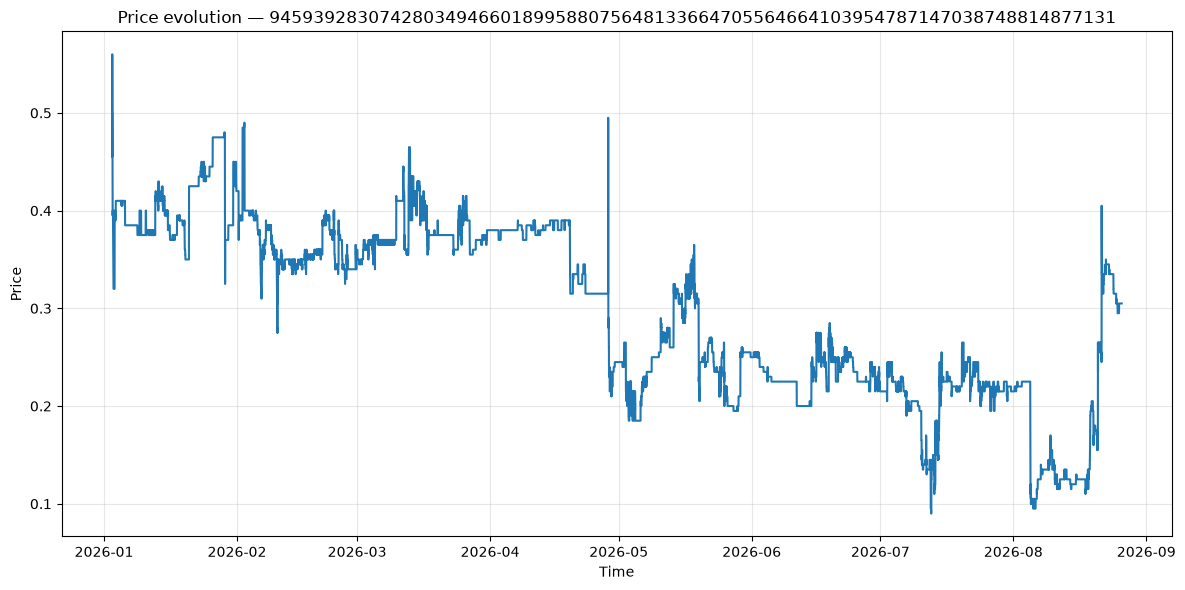

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Player/token you want
market_index = 875

# Filter to this player
player_df = price_history_df[price_history_df["market_index"] == market_index].copy()

# Convert timestamp
player_df["timestamp"] = pd.to_datetime(player_df["timestamp"], utc=True)

# Sort chronologically
player_df = player_df.sort_values("timestamp")

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    player_df["timestamp"],
    player_df["price"],
    linewidth=1.5
)

plt.xlabel("Time")
plt.ylabel("Price")
plt.title(f"Price evolution — {token_id}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
price_history_df.to_parquet("tennis_price_history_df.parquet")